In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/maryammoghaddasbayat/carsmarketanalysis/autoscout24_16and10200.csv


NOTEBOOK 2: RQ2 - MODEL COMPARISON

[1] Loading and cleaning dataset...
✅ Loaded: autoscout24_16and10200.csv
Dataset shape after cleaning: (10200, 16)

[2] Preparing features and target...
Features (9): ['mileage_km', 'power_hp', 'vehicle_age', 'brand_premium', 'weight_kg', 'cylinders_volume_cc', 'nr_doors', 'fuel_category', 'transmission']

[3] Train-test split and scaling...
Training: 8,160, Test: 2,040

[4] Training all models...
  Training Linear Regression...
    R² = 0.5701
  Training Decision Tree...
    R² = 0.8921
  Training Random Forest...
    R² = 0.9301
  Training XGBoost...
    R² = 0.9073
  Training SVM (RBF)...
    R² = -0.0543
  Training k-NN (k=5)...
    R² = 0.8769
  Training Neural Network...
    R² = 0.6821

[5] Creating Table II...

-------------------------------------------------------------------------------------
TABLE II: Model Comparison
-------------------------------------------------------------------------------------
Model                MAE (€)        

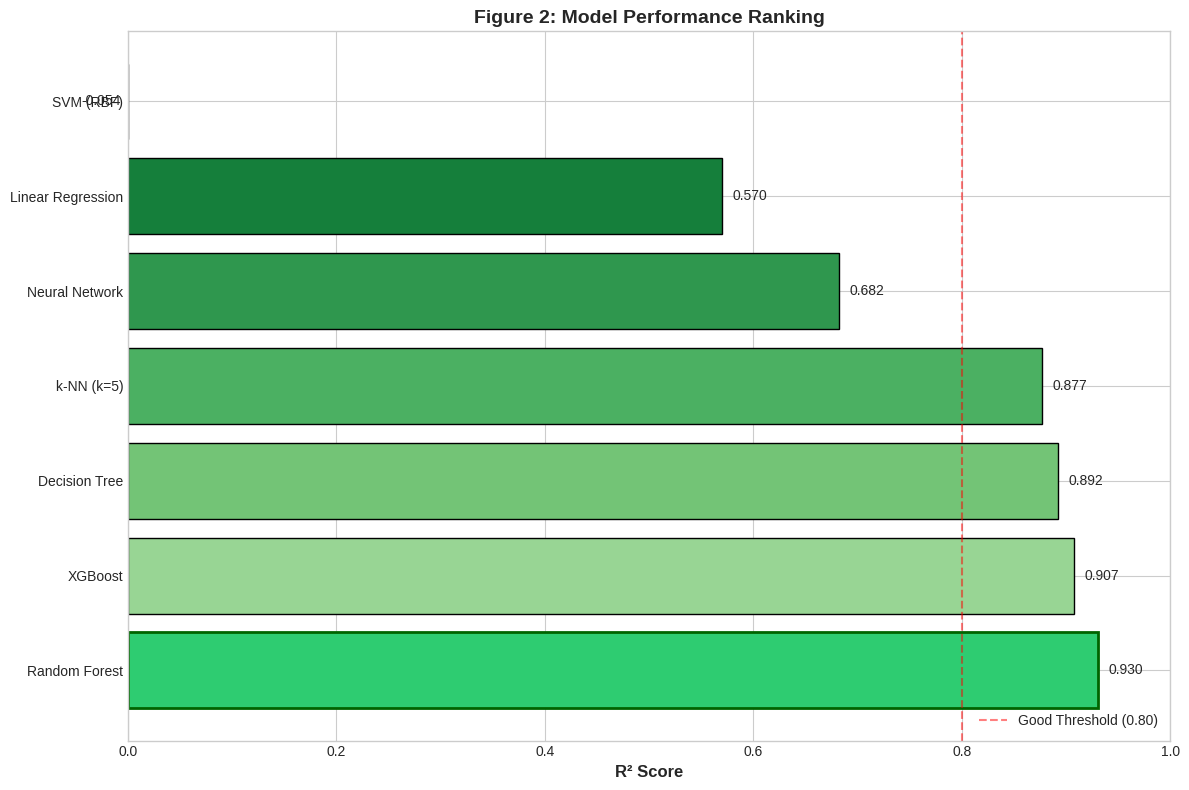

✅ Saved: /kaggle/working/Figure2_Model_Ranking.pdf

NOTEBOOK 2 COMPLETE

🏆 Best Model: Random Forest
   R² = 0.9301
   MAE = €5,105

📁 Output saved to: /kaggle/working


In [3]:
# ==============================================================================
# NOTEBOOK 2: RQ2 - MODEL COMPARISON
# Dataset: autoscout24_16and10200
# Kernel: cars-marketanalysis-rq2
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)

print("=" * 70)
print("NOTEBOOK 2: RQ2 - MODEL COMPARISON")
print("=" * 70)

# ==============================================================================
# LOAD AND CLEAN DATASET
# ==============================================================================
print("\n[1] Loading and cleaning dataset...")

input_dir = '/kaggle/input'
df = None

for root, dirs, files in os.walk(input_dir):
    for file in files:
        if file.endswith('.csv') and ('autoscout24' in file.lower() or '16and10200' in file):
            df = pd.read_csv(os.path.join(root, file))
            print(f"✅ Loaded: {file}")
            break
    if df is not None:
        break

if df is None:
    for root, dirs, files in os.walk(input_dir):
        for file in files:
            if file.endswith('.csv'):
                df = pd.read_csv(os.path.join(root, file))
                print(f"✅ Loaded: {file}")
                break
        if df is not None:
            break

def clean_mileage(value):
    if isinstance(value, str):
        cleaned = re.sub(r'[^\d.]', '', value.replace(',', ''))
        try:
            return float(cleaned)
        except:
            return np.nan
    return value

def clean_weight(value):
    if isinstance(value, str):
        cleaned = re.sub(r'[^\d.]', '', value.replace(',', ''))
        try:
            return float(cleaned)
        except:
            return np.nan
    return value

if 'mileage_km' in df.columns:
    df['mileage_km'] = df['mileage_km'].apply(clean_mileage)
if 'weight_kg' in df.columns:
    df['weight_kg'] = df['weight_kg'].apply(clean_weight)

numeric_cols = ['power_hp', 'power_kw', 'cylinders_volume_cc', 'nr_doors', 'vehicle_age', 'brand_premium']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df_clean = df.dropna()
print(f"Dataset shape after cleaning: {df_clean.shape}")

# ==============================================================================
# PREPARE FEATURES AND TARGET
# ==============================================================================
print("\n[2] Preparing features and target...")

target_col = 'price'
y = df_clean[target_col]

# Feature columns
feature_cols = ['mileage_km', 'power_hp', 'vehicle_age', 'brand_premium', 
                'weight_kg', 'cylinders_volume_cc', 'nr_doors']
available_features = [f for f in feature_cols if f in df_clean.columns]
X = df_clean[available_features].copy()

# Add categorical features
categorical_cols = ['fuel_category', 'transmission']
for col in categorical_cols:
    if col in df_clean.columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(df_clean[col].astype(str))
        available_features.append(col)

print(f"Features ({len(available_features)}): {available_features}")

# ==============================================================================
# TRAIN-TEST SPLIT AND SCALING
# ==============================================================================
print("\n[3] Train-test split and scaling...")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training: {X_train.shape[0]:,}, Test: {X_test.shape[0]:,}")

# ==============================================================================
# TRAIN ALL MODELS
# ==============================================================================
print("\n[4] Training all models...")

def evaluate_model(model, X_train, y_train, X_test, y_test, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return {
        'Model': name,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred),
        'MAPE': np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    }

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100),
    'XGBoost': XGBRegressor(random_state=42, n_estimators=100, learning_rate=0.1),
    'SVM (RBF)': SVR(kernel='rbf', C=1.0),
    'k-NN (k=5)': KNeighborsRegressor(n_neighbors=5),
    'Neural Network': MLPRegressor(random_state=42, hidden_layer_sizes=(100, 50), max_iter=500)
}

results = []
for name, model in models.items():
    print(f"  Training {name}...")
    try:
        result = evaluate_model(model, X_train_scaled, y_train, X_test_scaled, y_test, name)
        results.append(result)
        print(f"    R² = {result['R2']:.4f}")
    except Exception as e:
        print(f"    Error: {e}")

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)

# ==============================================================================
# CREATE TABLE II
# ==============================================================================
print("\n[5] Creating Table II...")

print("\n" + "-" * 85)
print("TABLE II: Model Comparison")
print("-" * 85)
print(f"{'Model':<20} {'MAE (€)':<15} {'RMSE (€)':<15} {'R²':<12} {'MAPE (%)':<12}")
print("-" * 85)
for _, row in results_df.iterrows():
    print(f"{row['Model']:<20} €{row['MAE']:>12,.0f} €{row['RMSE']:>12,.0f} "
          f"{row['R2']:>10.4f} {row['MAPE']:>10.1f}%")
print("-" * 85)

output_dir = '/kaggle/working'
results_df.to_csv(f'{output_dir}/TableII_Model_Comparison.csv', index=False)
print(f"\n✅ Saved: {output_dir}/TableII_Model_Comparison.csv")

# ==============================================================================
# CREATE FIGURE 2
# ==============================================================================
print("\n[6] Creating Figure 2...")

fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.Greens(np.linspace(0.3, 0.9, len(results_df)))
bars = ax.barh(results_df['Model'], results_df['R2'], color=colors, edgecolor='black')

ax.set_xlim(0, 1)
ax.set_xlabel('R² Score', fontsize=12, fontweight='bold')
ax.set_title('Figure 2: Model Performance Ranking', fontsize=14, fontweight='bold')

# Highlight best model
best_idx = results_df['R2'].argmax()
bars[best_idx].set_color('#2ecc71')
bars[best_idx].set_edgecolor('darkgreen')
bars[best_idx].set_linewidth(2)

for bar, score in zip(bars, results_df['R2']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{score:.3f}', va='center', fontsize=10)

ax.axvline(x=0.80, color='red', linestyle='--', alpha=0.5, label='Good Threshold (0.80)')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(f'{output_dir}/Figure2_Model_Ranking.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{output_dir}/Figure2_Model_Ranking.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved: {output_dir}/Figure2_Model_Ranking.pdf")

# ==============================================================================
# SUMMARY
# ==============================================================================
print("\n" + "=" * 70)
print("NOTEBOOK 2 COMPLETE")
print("=" * 70)
print(f"\n🏆 Best Model: {results_df.iloc[0]['Model']}")
print(f"   R² = {results_df.iloc[0]['R2']:.4f}")
print(f"   MAE = €{results_df.iloc[0]['MAE']:,.0f}")
print(f"\n📁 Output saved to: {output_dir}")
print("=" * 70)

In [1]:
# ==============================================================================
# NOTEBOOK 2: RQ2 - MODEL COMPARISON
# Dataset: autoscout24_16and10200
# Kernel: cars-marketanalysis-rq2
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)

print("=" * 70)
print("NOTEBOOK 2: RQ2 - MODEL COMPARISON")
print("=" * 70)

# ==============================================================================
# LOAD AND CLEAN DATASET
# ==============================================================================
print("\n[1] Loading and cleaning dataset...")

input_dir = '/kaggle/input'
df = None

for root, dirs, files in os.walk(input_dir):
    for file in files:
        if file.endswith('.csv') and ('autoscout24' in file.lower() or '16and10200' in file):
            df = pd.read_csv(os.path.join(root, file))
            print(f"✅ Loaded: {file}")
            break
    if df is not None:
        break

if df is None:
    for root, dirs, files in os.walk(input_dir):
        for file in files:
            if file.endswith('.csv'):
                df = pd.read_csv(os.path.join(root, file))
                print(f"✅ Loaded: {file}")
                break
        if df is not None:
            break

def clean_mileage(value):
    if isinstance(value, str):
        cleaned = re.sub(r'[^\d.]', '', value.replace(',', ''))
        try:
            return float(cleaned)
        except:
            return np.nan
    return value

def clean_weight(value):
    if isinstance(value, str):
        cleaned = re.sub(r'[^\d.]', '', value.replace(',', ''))
        try:
            return float(cleaned)
        except:
            return np.nan
    return value

if 'mileage_km' in df.columns:
    df['mileage_km'] = df['mileage_km'].apply(clean_mileage)
if 'weight_kg' in df.columns:
    df['weight_kg'] = df['weight_kg'].apply(clean_weight)

numeric_cols = ['power_hp', 'power_kw', 'cylinders_volume_cc', 'nr_doors', 'vehicle_age', 'brand_premium']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df_clean = df.dropna()
print(f"Dataset shape after cleaning: {df_clean.shape}")

# ==============================================================================
# PREPARE FEATURES AND TARGET
# ==============================================================================
print("\n[2] Preparing features and target...")

target_col = 'price'
y = df_clean[target_col]

# Feature columns
feature_cols = ['mileage_km', 'power_hp', 'vehicle_age', 'brand_premium', 
                'weight_kg', 'cylinders_volume_cc', 'nr_doors']
available_features = [f for f in feature_cols if f in df_clean.columns]
X = df_clean[available_features].copy()

# Add categorical features
categorical_cols = ['fuel_category', 'transmission']
for col in categorical_cols:
    if col in df_clean.columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(df_clean[col].astype(str))
        available_features.append(col)

print(f"Features ({len(available_features)}): {available_features}")

# ==============================================================================
# TRAIN-TEST SPLIT AND SCALING
# ==============================================================================
print("\n[3] Train-test split and scaling...")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training: {X_train.shape[0]:,}, Test: {X_test.shape[0]:,}")

# ==============================================================================
# TRAIN ALL MODELS
# ==============================================================================
print("\n[4] Training all models...")

def evaluate_model(model, X_train, y_train, X_test, y_test, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return {
        'Model': name,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred),
        'MAPE': np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    }

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100),
    'XGBoost': XGBRegressor(random_state=42, n_estimators=100, learning_rate=0.1),
    'SVM (RBF)': SVR(kernel='rbf', C=1.0),
    'k-NN (k=5)': KNeighborsRegressor(n_neighbors=5),
    'Neural Network': MLPRegressor(random_state=42, hidden_layer_sizes=(100, 50), max_iter=500)
}

results = []
for name, model in models.items():
    print(f"  Training {name}...")
    try:
        result = evaluate_model(model, X_train_scaled, y_train, X_test_scaled, y_test, name)
        results.append(result)
        print(f"    R² = {result['R2']:.4f}")
    except Exception as e:
        print(f"    Error: {e}")

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)

# ==============================================================================
# CREATE TABLE II
# ==============================================================================
print("\n[5] Creating Table II...")

print("\n" + "-" * 85)
print("TABLE II: Model Comparison")
print("-" * 85)
print(f"{'Model':<20} {'MAE (€)':<15} {'RMSE (€)':<15} {'R²':<12} {'MAPE (%)':<12}")
print("-" * 85)
for _, row in results_df.iterrows():
    print(f"{row['Model']:<20} €{row['MAE']:>12,.0f} €{row['RMSE']:>12,.0f} "
          f"{row['R2']:>10.4f} {row['MAPE']:>10.1f}%")
print("-" * 85)

output_dir = '/kaggle/working'
results_df.to_csv(f'{output_dir}/TableII_Model_Comparison.csv', index=False)
print(f"\n✅ Saved: {output_dir}/TableII_Model_Comparison.csv")

# ==============================================================================
# CREATE FIGURE 2
# ==============================================================================
print("\n[6] Creating Figure 2...")

fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.Greens(np.linspace(0.3, 0.9, len(results_df)))
bars = ax.barh(results_df['Model'], results_df['R2'], color=colors, edgecolor='black')

ax.set_xlim(0, 1)
ax.set_xlabel('R² Score', fontsize=12, fontweight='bold')
ax.set_title('Figure 2: Model Performance Ranking', fontsize=14, fontweight='bold')

# Highlight best model
best_idx = results_df['R2'].argmax()
bars[best_idx].set_color('#2ecc71')
bars[best_idx].set_edgecolor('darkgreen')
bars[best_idx].set_linewidth(2)

for bar, score in zip(bars, results_df['R2']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{score:.3f}', va='center', fontsize=10)

ax.axvline(x=0.80, color='red', linestyle='--', alpha=0.5, label='Good Threshold (0.80)')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(f'{output_dir}/Figure2_Model_Ranking.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{output_dir}/Figure2_Model_Ranking.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved: {output_dir}/Figure2_Model_Ranking.pdf")

# ==============================================================================
# SUMMARY
# ==============================================================================
print("\n" + "=" * 70)
print("NOTEBOOK 2 COMPLETE")
print("=" * 70)
print(f"\n🏆 Best Model: {results_df.iloc[0]['Model']}")
print(f"   R² = {results_df.iloc[0]['R2']:.4f}")
print(f"   MAE = €{results_df.iloc[0]['MAE']:,.0f}")
print(f"\n📁 Output saved to: {output_dir}")
print("=" * 70)

NOTEBOOK 2: RQ2 - MODEL COMPARISON

[1] Loading and cleaning dataset...


AttributeError: 'NoneType' object has no attribute 'columns'